# Задание Ultra Pro

Используя базу "Пассажиры автобуса", подготовьте данные для обучения нейронной сети, классифицирующей изображение на два класса:
- входящий пассажир
- выходящий пассажир

Добейтесь точности работы модели на проверочной выборке не ниже 85%

Ссылка на датасет: https://storage.yandexcloud.net/aiueducation/Content/base/l4/bus.zip

In [1]:
from tensorflow import keras
import tensorflow as tf
from keras.layers import Dense, Flatten
from keras.models import Sequential
from keras.optimizers import Adam
from keras import utils
from keras.preprocessing import image
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import os
%matplotlib inline

In [2]:
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l4/bus.zip', None, quiet = True)
!unzip -q bus.zip -d /content/

In [3]:
class BusPassanger:
    def __init__(self, epochs=64, batch_size=8):
      self.epochs = epochs
      self.batch_size = batch_size

    def load_dataset(self):
      # Путь к директории с базой
      base_dir = '/content'
      # Создание пустого списка для загрузки изображений обучающей выборки
      x_data = []
      # Создание списка для меток классов
      y_data = []
      # Задание высоты и ширины загружаемых изображений
      img_height = 120
      img_width = 80
      # Перебор папок в директории базы
      for patch in os.listdir(base_dir):
        # Пропуск лишнего
          if patch not in ['Входящий', 'Выходящий']:
              continue
          # Перебор файлов в папках
          for img in os.listdir(base_dir + '/' + patch):
              img_path = base_dir + '/' + patch + '/' + img
              # Добавление в список изображений текущей картинки
              x_data.append(image.img_to_array(image.load_img(img_path,
                                                          target_size=(img_height, img_width),
                                                          color_mode='grayscale')))
              # Добавление в массив меток, соответствующих классам
              if patch == 'Входящий':
                  y_data.append(0)
              else:
                  y_data.append(1)

      # Преобразование в numpy-массив загруженных изображений и меток классов
      x_data = np.array(x_data)
      y_data = np.array(y_data)

      x_data = x_data.astype("float32") / 255.0

      return x_data, y_data

    # загрузка данных
    def load_data(self):
      x_data, y_data = self.load_dataset()

      np.random.seed(42)
      tf.keras.utils.set_random_seed(42)

      x_train_val, x_test, y_train_val, y_test = train_test_split(
              x_data,
              y_data,
              test_size=0.2,
              random_state=42,
              stratify=y_data
        )

      x_train, x_val, y_train, y_val = train_test_split(
              x_train_val,
              y_train_val,
              test_size=0.25,   # 0.25 от 0.8 = 0.2 от всего набора
              random_state=42,
              stratify=y_train_val
        )

      return x_train, y_train, x_val, y_val, x_test, y_test

    # создание модели
    def create_model(self):
        model = Sequential()

        # распрямление картинки в строку чисел
        model.add(Flatten(input_shape = (120, 80, 1)))
        model.add(Dense(256, activation = 'relu'))
        model.add(Dense(32, activation = 'relu'))
        model.add(Dense(2, activation = 'sigmoid'))

        model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

        return model

    # обучение модели
    def train_model(self):
        x_train, y_train, x_val, y_val, x_test, y_test = self.load_data()
        model = self.create_model()

        # ранняя остановка, чтобы избежать переобучения и снижения точности
        early_stop = EarlyStopping(monitor = 'val_accuracy', patience = 4, restore_best_weights = True)

        history = model.fit(x_train, y_train, epochs=self.epochs, batch_size=self.batch_size, verbose=1, shuffle=True, validation_data=(x_val, y_val), callbacks = [early_stop])

        test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

        return history, test_loss, test_accuracy

    def plot_history(self, history):
        plt.figure(figsize=(8, 5))
        plt.plot(history.history['loss'], label='Ошибка на обучении')
        plt.plot(history.history['val_loss'], label='Ошибка на валидации')
        plt.title('График ошибки')
        plt.xlabel('Эпоха')
        plt.ylabel('Ошибка')
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(8, 5))
        plt.plot(history.history['accuracy'], label='Точность на обучении')
        plt.plot(history.history['val_accuracy'], label='Точность на валидации')
        plt.title('График точности')
        plt.xlabel('Эпоха')
        plt.ylabel('Точность')
        plt.legend()
        plt.grid(True)
        plt.show()

In [4]:
model = BusPassanger(epochs = 40, batch_size = 32)
history, loss, accuracy = model.train_model()
print(accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.7069 - loss: 0.6209 - val_accuracy: 0.7533 - val_loss: 0.5465
Epoch 2/40
171/171 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.7531 - loss: 0.5338 - val_accuracy: 0.7329 - val_loss: 0.5265
Epoch 3/40
171/171 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.7562 - loss: 0.5097 - val_accuracy: 0.7709 - val_loss: 0.4943
Epoch 4/40
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.7757 - loss: 0.4846 - val_accuracy: 0.7803 - val_loss: 0.4805
Epoch 5/40
171/171 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.7838 - loss: 0.4740 - val_accuracy: 0.7924 - val_loss: 0.4576
Epoch 6/40
171/171 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.7937 - loss: 0.4541 - val_accuracy: 0.7990 - val_loss: 0.4453
Epoch 7/40
171/171 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.8078 - loss: 0.4204 - val_accuracy: 0.8188 - val_loss: 0.4081
Epoch 8/40
171/171 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.8262 - loss: 0.3828 - val_a

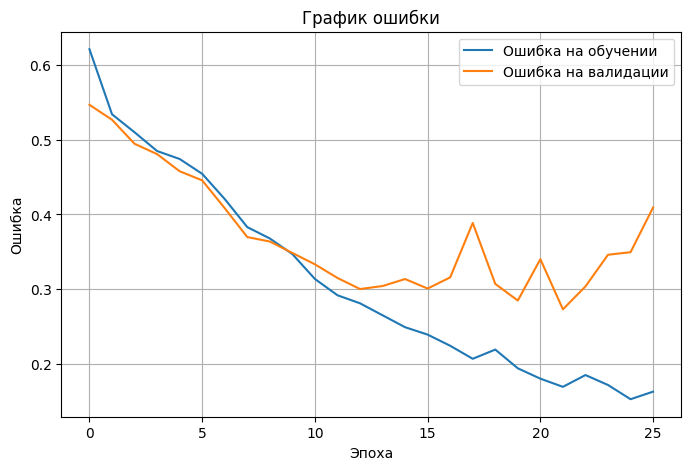

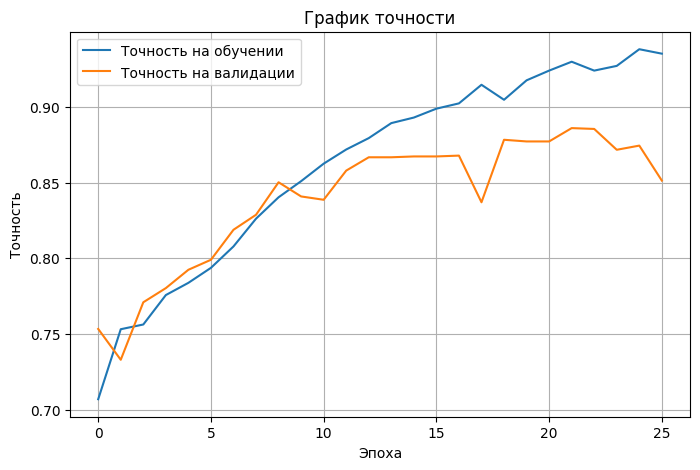

In [5]:
model.plot_history(history)